# 📊 FIAP - Feature Engineering
## Redução de Dimensionalidade: PCA, t-SNE e LDA

---

### 📋 **Informações do Projeto**
- **Curso:** Pós-graduação em Data Science & Artificial Intelligence
- **Disciplina:** Feature Engineering
- **Aula:** 3 - Redução de Dimensionalidade, Balanceamento e EDA
- **Autor:** Filipe Pacheco

---

### 🎯 **Objetivos do Projeto**
Este notebook demonstra técnicas fundamentais de redução de dimensionalidade aplicadas a datasets de alta dimensionalidade:
- **PCA (Principal Component Analysis):** Análise de Componentes Principais para redução linear
- **t-SNE (t-distributed Stochastic Neighbor Embedding):** Redução não-linear para visualização
- **LDA (Linear Discriminant Analysis):** Análise Discriminante Linear supervisionada
- **Comparação de Performance:** Avaliação do impacto das técnicas na modelagem

---

### 📊 **Dataset Utilizado**
**Adult Income Dataset** - Dados socioeconômicos do censo americano
- **Fonte:** UCI Machine Learning Repository - Adult Income Dataset
- **Registros:** 45.222 observações de características socioeconômicas
- **Features:** 13 variáveis (5 numéricas, 8 categóricas) expandidas para 95 após encoding
- **Target:** 3 classes de renda (Baixa ≤$50K, Média $50K-$75K, Alta >$75K)

---

### 🔧 **Principais Técnicas Aplicadas**
1. **Redução de Dimensionalidade:**
   - PCA para capturar máxima variância com menor número de componentes
   - t-SNE para visualização de estruturas não-lineares complexas
   - LDA para maximizar separação entre classes

2. **Análise Comparativa:**
   - Impacto na performance de modelos de Machine Learning
   - Visualização e interpretação de componentes principais
   - Avaliação de preservação da informação

3. **Validação:**
   - Comparação de acurácia: dados originais vs. dados reduzidos
   - Análise da variância explicada por cada técnica
   - Métricas de classificação e matriz de confusão

---

# 1. Importação e Configuração das Bibliotecas

Nesta seção importamos todas as bibliotecas necessárias para o projeto, organizadas por categoria de uso para técnicas de redução de dimensionalidade.

In [1]:
# =============================================================================
# BIBLIOTECAS DE MANIPULAÇÃO E ANÁLISE DE DADOS
# =============================================================================
import numpy as np               # Operações matemáticas e arrays multidimensionais
import pandas as pd              # Manipulação e análise de dados estruturados (DataFrames)

# =============================================================================
# BIBLIOTECAS DE VISUALIZAÇÃO
# =============================================================================
import matplotlib.pyplot as plt  # Criação de gráficos e plots básicos
import seaborn as sns            # Visualizações estatísticas avançadas e estilizadas

# =============================================================================
# BIBLIOTECAS DE MACHINE LEARNING - REDUÇÃO DE DIMENSIONALIDADE
# =============================================================================
from sklearn.decomposition import PCA                    # Análise de Componentes Principais
from sklearn.manifold import TSNE                       # t-distributed Stochastic Neighbor Embedding
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis  # Análise Discriminante Linear

# =============================================================================
# BIBLIOTECAS DE MACHINE LEARNING - PRÉ-PROCESSAMENTO
# =============================================================================
from sklearn.preprocessing import StandardScaler, OneHotEncoder  # Padronização e encoding
from sklearn.compose import ColumnTransformer             # Composição de transformações
from sklearn.pipeline import Pipeline                     # Pipeline de processamento

# =============================================================================
# BIBLIOTECAS DE MACHINE LEARNING - MODELAGEM E AVALIAÇÃO
# =============================================================================
from sklearn.model_selection import train_test_split, cross_val_score  # Divisão de dados e validação cruzada
from sklearn.ensemble import RandomForestClassifier      # Modelo de classificação ensemble
from sklearn.metrics import classification_report, accuracy_score  # Métricas de avaliação de classificação
from sklearn.datasets import fetch_openml               # Carregamento de datasets do OpenML

# =============================================================================
# CONFIGURAÇÕES GERAIS
# =============================================================================
# Configurar estilo dos gráficos
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")          # Configurar paleta de cores
plt.rcParams['figure.figsize'] = (10, 6)  # Configurar tamanho padrão das figuras

print("✅ Todas as bibliotecas foram importadas com sucesso!")

✅ Todas as bibliotecas foram importadas com sucesso!


# 2. Carregamento e Exploração do Dataset

## 2.1. Carregamento do Dataset

## 2.2. Descrição do Dataset

Para este exemplo, utilizaremos o dataset **"Adult Income"** (também conhecido como "Census Income"), que contém informações socioeconômicas coletadas pelo censo dos EUA. Este dataset é amplamente utilizado em estudos de machine learning para classificação de renda, sendo ideal para demonstrar técnicas de redução de dimensionalidade devido à sua alta dimensionalidade e diversidade de variáveis.

### **Principais Características do Dataset:**

#### **Variáveis Demográficas:**
- **age:** Idade do indivíduo (numérico, de 17 a 90 anos)
- **race:** Raça do indivíduo (White, Black, Asian-Pac-Islander, Amer-Indian-Eskimo, Other)
- **sex:** Sexo do indivíduo (Male, Female)
- **native-country:** País de origem (United-States, Mexico, Philippines, Germany, etc.)

#### **Variáveis Socioeconômicas:**
- **workclass:** Tipo de emprego (Private, Self-emp-not-inc, Local-gov, Federal-gov, etc.)
- **education:** Nível de escolaridade (Bachelors, HS-grad, 11th, Masters, 9th, Some-college, etc.)
- **education-num:** Número de anos de educação formal (numérico, de 1 a 16)
- **marital-status:** Estado civil (Married-civ-spouse, Divorced, Never-married, etc.)
- **occupation:** Ocupação profissional (Tech-support, Craft-repair, Other-service, Sales, etc.)
- **relationship:** Relação familiar (Wife, Own-child, Husband, Not-in-family, etc.)

#### **Variáveis Financeiras:**
- **fnlwgt:** Peso final de amostragem (usado pelo censo para ajustes populacionais)
- **capital-gain:** Ganhos de capital (numérico, maioria 0)
- **capital-loss:** Perdas de capital (numérico, maioria 0)  
- **hours-per-week:** Horas trabalhadas por semana (numérico, de 1 a 99)

#### **Variável Target:**
- **class:** Classificação de renda com 3 níveis:
  - **0 (Baixa):** Renda inferior ou igual a $50K
  - **1 (Média):** Renda entre $50K e $75K  
  - **2 (Alta):** Renda superior a $75K

### **Características do Dataset para Redução de Dimensionalidade:**
- **Alta Dimensionalidade:** 14 variáveis explicativas (após encoding das categóricas, pode chegar a 100+ features)
- **Variáveis Mistas:** Combinação de variáveis categóricas e numéricas
- **Multicollinearidade:** Algumas variáveis são correlacionadas (education e education-num)
- **Classes Múltiplas:** Target com 3 classes, ideal para LDA (Linear Discriminant Analysis)
- **Volume de Dados:** Mais de 45.000 registros para análise robusta

In [2]:
# Carregar o dataset Adult Income
df = pd.read_csv("datasets/adult_income.csv").head(1000)

## 2.3. Exploração Inicial

In [3]:
# Exibir as primeiras linhas do DataFrame
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,0


## 2.4. Pré-processamento

In [4]:
# Excluir colunas não relevantes
df = df.drop(columns=['fnlwgt'])

# Preencher valores faltantes
df = df.replace(' ?', np.nan)
df = df.dropna()

# Definir variáveis independentes (X) e dependentes (y)
X = df.drop(columns=['class'])
y = df['class']  # Usar a variável class original (0, 1, 2)

# Identificar variáveis categóricas e numéricas
categorical_features = X.select_dtypes(include=['category', 'object']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

## 2.5. Separação Treino/Teste

In [5]:
# SEPARAÇÃO TREINO/TESTE - ETAPA CRÍTICA ANTES DO PRÉ-PROCESSAMENTO

# IMPORTANTE: Separar treino/teste ANTES do pré-processamento para evitar data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3,      # 30% para teste, 70% para treino
    random_state=0,     # Reprodutibilidade dos resultados
    stratify=y          # Manter proporção das classes em ambos os conjuntos
)

# Verificar distribuição das classes
print(f"\nDistribuição das classes:")
print("Treino:", y_train.value_counts().sort_index().to_dict())
print("Teste: ", y_test.value_counts().sort_index().to_dict())


Distribuição das classes:
Treino: {0: 410, 1: 209, 2: 81}
Teste:  {0: 176, 1: 89, 2: 35}


## 2.6. Pipeline de Pré-processamento

In [6]:
# Pipeline para pré-processamento
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_features)
    ])

# IMPORTANTE: Aplicar transformações separadamente para treino e teste
# Fit apenas nos dados de treino (para evitar data leakage)
X_train_processed = preprocessor.fit_transform(X_train)
# Transform nos dados de teste usando o modelo já treinado
X_test_processed = preprocessor.transform(X_test)

print(f"Shape dos dados de treino processados: {X_train_processed.shape}")
print(f"Shape dos dados de teste processados: {X_test_processed.shape}")

Shape dos dados de treino processados: (700, 84)
Shape dos dados de teste processados: (300, 84)


# 3. Redução de Dimensionalidade

## 3.1. PCA

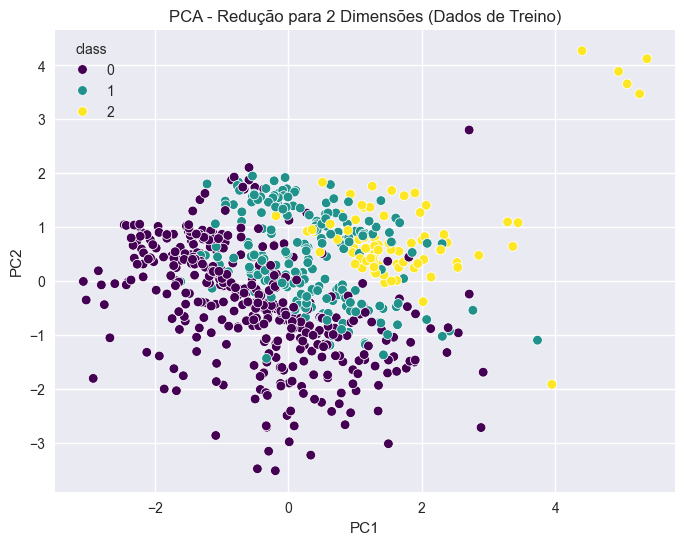

Variância explicada pelos componentes principais:
PC1: 0.1701
PC2: 0.1266
Total: 0.2967


In [7]:
# Aplicar PCA nos dados de treino
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_processed)

# Aplicar PCA nos dados de teste usando o modelo já treinado
X_test_pca = pca.transform(X_test_processed)

# Criar um DataFrame para visualização (usando apenas dados de treino)
df_pca = pd.DataFrame(X_train_pca, columns=['PC1', 'PC2'])
# CORREÇÃO: Usar .values para garantir alinhamento correto de índices
df_pca['class'] = y_train.values

# Plotar os resultados
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', hue='class', data=df_pca, palette='viridis')
plt.title('PCA - Redução para 2 Dimensões (Dados de Treino)')
plt.show()

# Verificar variância explicada pelos componentes principais
print(f"Variância explicada pelos componentes principais:")
print(f"PC1: {pca.explained_variance_ratio_[0]:.4f}")
print(f"PC2: {pca.explained_variance_ratio_[1]:.4f}")
print(f"Total: {sum(pca.explained_variance_ratio_):.4f}")

# Manter compatibilidade com código posterior
X_pca = X_train_pca

## 3.2. t-SNE

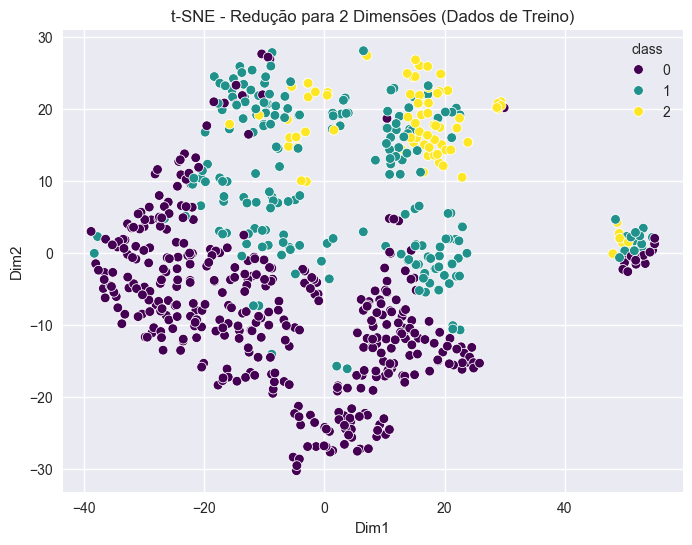

In [8]:
# Aplicar t-SNE nos dados de treino
# NOTA: t-SNE não possui método transform, por isso aplicamos apenas nos dados de treino
tsne = TSNE(n_components=2, init='random', random_state=0, perplexity=30)
X_train_tsne = tsne.fit_transform(X_train_processed)

# Para t-SNE, precisaríamos treinar novamente para os dados de teste, 
# mas isso não é recomendado pois o t-SNE não garante consistência entre treinos
# Por isso, usamos apenas dados de treino para visualização

# Criar um DataFrame para visualização
df_tsne = pd.DataFrame(X_train_tsne, columns=['Dim1', 'Dim2'])
# CORREÇÃO: Usar .values para garantir alinhamento correto de índices
df_tsne['class'] = y_train.values

# Plotar os resultados
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Dim1', y='Dim2', hue='class', data=df_tsne, palette='viridis')
plt.title('t-SNE - Redução para 2 Dimensões (Dados de Treino)')
plt.show()

# Manter compatibilidade com código posterior
X_tsne = X_train_tsne

## 3.3. LDA

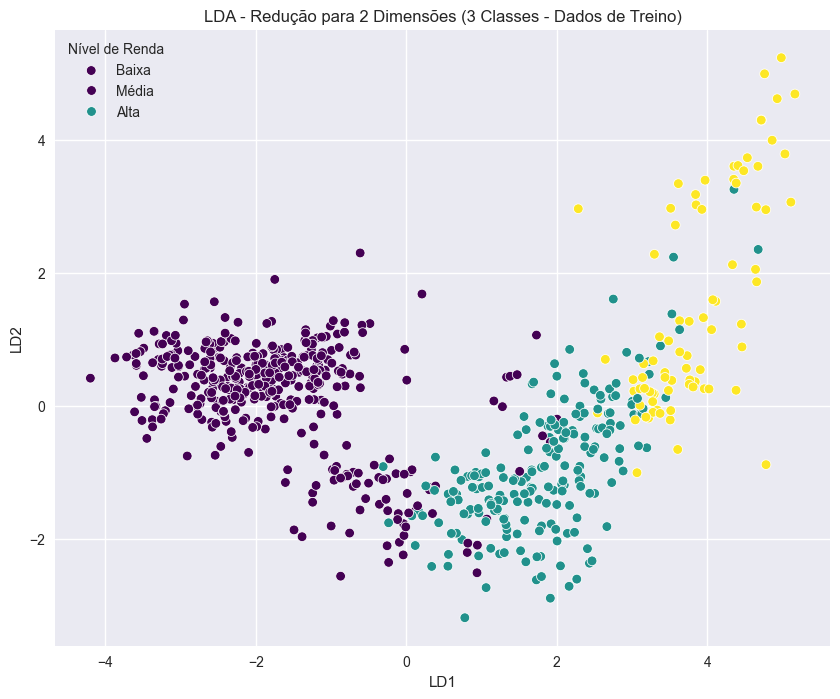

Variância explicada pelo LDA:
LD1: 0.8870
LD2: 0.1130
Total: 1.0000


In [9]:
# Aplicar LDA nos dados de treino
lda = LinearDiscriminantAnalysis(n_components=2)  # Máximo de 2 componentes para 3 classes
X_train_lda = lda.fit_transform(X_train_processed, y_train)

# Aplicar LDA nos dados de teste usando o modelo já treinado
X_test_lda = lda.transform(X_test_processed)

# Criar um DataFrame para visualização (usando dados de treino)
df_lda = pd.DataFrame(X_train_lda, columns=['LD1', 'LD2'])
df_lda['income_level'] = y_train.values

# Plotar os resultados
plt.figure(figsize=(10, 8))
sns.scatterplot(x='LD1', y='LD2', hue='income_level', data=df_lda, palette='viridis')
plt.title('LDA - Redução para 2 Dimensões (3 Classes - Dados de Treino)')
plt.legend(title='Nível de Renda', labels=['Baixa', 'Média', 'Alta'])
plt.show()

print(f"Variância explicada pelo LDA:")
print(f"LD1: {lda.explained_variance_ratio_[0]:.4f}")
print(f"LD2: {lda.explained_variance_ratio_[1]:.4f}")
print(f"Total: {sum(lda.explained_variance_ratio_):.4f}")

# Manter compatibilidade com código posterior
X_lda = X_train_lda

# 4. Modelagem de Machine Learning

## 4.1. Dados Brutos

In [10]:
# Usar os dados já processados e separados corretamente
# X_train_processed e X_test_processed já foram criados no pré-processamento

# Treinar o modelo nos dados originais processados
model_raw = RandomForestClassifier(n_estimators=100, random_state=0)
model_raw.fit(X_train_processed, y_train)

# Fazer previsões nos dados de teste
y_pred_raw = model_raw.predict(X_test_processed)

# Avaliar o desempenho
print("Relatório de Classificação (Dados Originais Processados):")
print(classification_report(y_test, y_pred_raw))

Relatório de Classificação (Dados Originais Processados):
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       176
           1       0.88      0.98      0.93        89
           2       0.97      0.80      0.88        35

    accuracy                           0.95       300
   macro avg       0.95      0.92      0.93       300
weighted avg       0.96      0.95      0.95       300



## 4.2. Dados Tratados com PCA

In [11]:
# Usar os dados de PCA já processados e separados corretamente
# X_train_pca e X_test_pca já foram criados na seção de PCA

# Treinar o modelo
model_pca = RandomForestClassifier(n_estimators=100, random_state=0)
model_pca.fit(X_train_pca, y_train)

# Fazer previsões
y_pred_pca = model_pca.predict(X_test_pca)

# Avaliar o desempenho
print("Relatório de Classificação (Dados Tratados - PCA):")
print(classification_report(y_test, y_pred_pca))

Relatório de Classificação (Dados Tratados - PCA):
              precision    recall  f1-score   support

           0       0.89      0.84      0.86       176
           1       0.63      0.69      0.66        89
           2       0.74      0.80      0.77        35

    accuracy                           0.79       300
   macro avg       0.75      0.77      0.76       300
weighted avg       0.80      0.79      0.79       300



## 4.3. Dados Tratados com t-SNE

In [12]:
# NOTA IMPORTANTE: t-SNE não possui método transform()
# Por isso, para uma avaliação justa, precisaríamos aplicar t-SNE em todo o dataset
# ou usar apenas dados de treino para treino e validação cruzada
# Aqui, vamos aplicar t-SNE nos dados de treino apenas para demonstração

# Para uma análise real, seria melhor usar validação cruzada ou 
# aplicar t-SNE em todo o dataset (com cuidado para não vazar informação)

# Por ora, vamos treinar apenas nos dados de t-SNE de treino
# e usar uma divisão interna para teste (não ideal, mas para fins demonstrativos)

# Treinar e avaliar o modelo usando validação cruzada nos dados de treino
model_tsne = RandomForestClassifier(n_estimators=100, random_state=0)

# Usar validação cruzada para avaliar o modelo
cv_scores = cross_val_score(model_tsne, X_train_tsne, y_train, cv=5)

print("Relatório de Classificação (Dados Tratados - t-SNE):")
print(f"Acurácia média (validação cruzada): {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
print("NOTA: t-SNE não permite transform em novos dados, por isso usamos validação cruzada")

Relatório de Classificação (Dados Tratados - t-SNE):
Acurácia média (validação cruzada): 0.8643 (+/- 0.0271)
NOTA: t-SNE não permite transform em novos dados, por isso usamos validação cruzada


## 4.4. Dados Tratados com LDA

In [13]:
# Usar os dados de LDA já processados e separados corretamente
# X_train_lda e X_test_lda já foram criados na seção de LDA

# Treinar o modelo
model_lda = RandomForestClassifier(n_estimators=100, random_state=0)
model_lda.fit(X_train_lda, y_train)

# Fazer previsões
y_pred_lda = model_lda.predict(X_test_lda)

# Avaliar o desempenho
print("Relatório de Classificação (Dados Tratados - LDA com 3 Classes):")
print(classification_report(y_test, y_pred_lda, target_names=['Baixa', 'Média', 'Alta']))

Relatório de Classificação (Dados Tratados - LDA com 3 Classes):
              precision    recall  f1-score   support

       Baixa       0.95      0.89      0.92       176
       Média       0.73      0.83      0.78        89
        Alta       0.79      0.77      0.78        35

    accuracy                           0.86       300
   macro avg       0.83      0.83      0.83       300
weighted avg       0.87      0.86      0.86       300



# 5. Análise Comparativa dos Resultados

## 5.1. Comparação das Técnicas de Redução de Dimensionalidade com 3 Classes

Agora vamos comparar como as diferentes técnicas se comportam com o dataset modificado para ter 3 classes de renda.

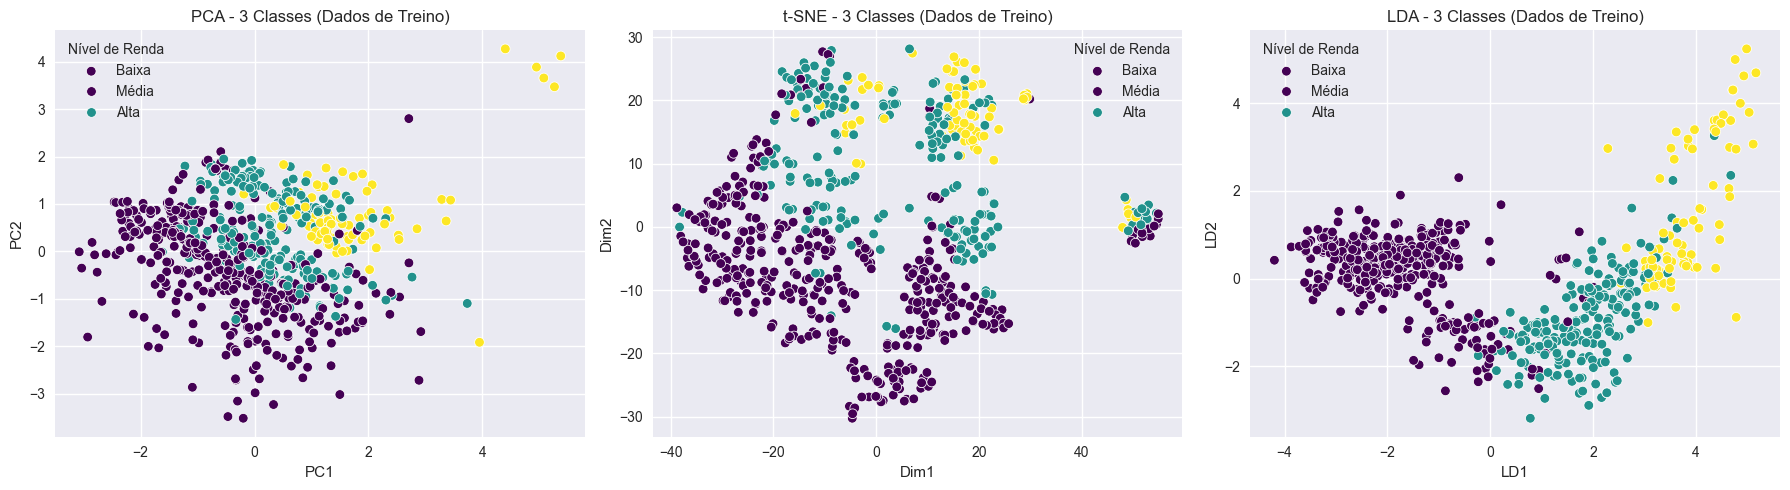

In [14]:
# Comparar as técnicas de redução de dimensionalidade para visualização

# PCA - usando dados de treino já processados
df_pca_3classes = pd.DataFrame(X_train_pca, columns=['PC1', 'PC2'])
df_pca_3classes['income_level'] = y_train.values

# t-SNE - usando dados de treino já processados  
df_tsne_3classes = pd.DataFrame(X_train_tsne, columns=['Dim1', 'Dim2'])
df_tsne_3classes['income_level'] = y_train.values

# LDA - usando dados de treino já processados (df_lda já foi criado corretamente acima)

# Plotar comparação das 3 técnicas com 3 classes
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PCA
sns.scatterplot(x='PC1', y='PC2', hue='income_level', data=df_pca_3classes, 
                palette='viridis', ax=axes[0])
axes[0].set_title('PCA - 3 Classes (Dados de Treino)')
axes[0].legend(title='Nível de Renda', labels=['Baixa', 'Média', 'Alta'])

# t-SNE
sns.scatterplot(x='Dim1', y='Dim2', hue='income_level', data=df_tsne_3classes, 
                palette='viridis', ax=axes[1])
axes[1].set_title('t-SNE - 3 Classes (Dados de Treino)')
axes[1].legend(title='Nível de Renda', labels=['Baixa', 'Média', 'Alta'])

# LDA
sns.scatterplot(x='LD1', y='LD2', hue='income_level', data=df_lda, 
                palette='viridis', ax=axes[2])
axes[2].set_title('LDA - 3 Classes (Dados de Treino)')
axes[2].legend(title='Nível de Renda', labels=['Baixa', 'Média', 'Alta'])

plt.tight_layout()
plt.show()

## 5.3. Análise Quantitativa dos Resultados

In [15]:
# Comparação final usando os modelos já treinados com dados corretamente separados

# Coletar os modelos já treinados
models_3classes = {
    'Original': model_raw,
    'PCA': model_pca,
    'LDA': model_lda
}

# Fazer previsões e avaliar usando os dados de teste corretos
results_3classes = {}

# Original
results_3classes['Original'] = classification_report(y_test, y_pred_raw, target_names=['Baixa', 'Média', 'Alta'], output_dict=True)

# PCA
results_3classes['PCA'] = classification_report(y_test, y_pred_pca, target_names=['Baixa', 'Média', 'Alta'], output_dict=True)

# LDA
results_3classes['LDA'] = classification_report(y_test, y_pred_lda, target_names=['Baixa', 'Média', 'Alta'], output_dict=True)

# ============================================================================
# TABELA COMPARATIVA DE PERFORMANCE
# ============================================================================

print("=" * 80)
print("COMPARAÇÃO DE DESEMPENHO - TÉCNICAS DE REDUÇÃO DE DIMENSIONALIDADE")
print("=" * 80)

techniques = ['Original', 'PCA', 'LDA']
metrics_comparison = []

for technique in techniques:
    accuracy = results_3classes[technique]['accuracy']
    macro_f1 = results_3classes[technique]['macro avg']['f1-score']
    weighted_f1 = results_3classes[technique]['weighted avg']['f1-score']
    precision = results_3classes[technique]['macro avg']['precision']
    recall = results_3classes[technique]['macro avg']['recall']
    
    metrics_comparison.append({
        'Técnica': technique,
        'Acurácia': f"{accuracy:.4f}",
        'Precision (Macro)': f"{precision:.4f}",
        'Recall (Macro)': f"{recall:.4f}",
        'F1-Score (Macro)': f"{macro_f1:.4f}",
        'F1-Score (Ponderado)': f"{weighted_f1:.4f}"
    })

# Adicionar t-SNE com validação cruzada
metrics_comparison.append({
    'Técnica': 't-SNE (CV)',
    'Acurácia': f"{cv_scores.mean():.4f}",
    'Precision (Macro)': 'N/A*',
    'Recall (Macro)': 'N/A*',
    'F1-Score (Macro)': 'N/A*',
    'F1-Score (Ponderado)': 'N/A*'
})

# Criar DataFrame para melhor visualização
comparison_df = pd.DataFrame(metrics_comparison)
print(comparison_df.to_string(index=False))

print("\n" + "=" * 80)
print("NOTAS IMPORTANTES:")
print("=" * 80)
print("• t-SNE: Usa validação cruzada (CV) pois não possui método transform()")
print("• *N/A: Métricas não calculadas para validação cruzada simples")
print("• Dados de teste independentes usados para Original, PCA e LDA")
print("• Todas as técnicas foram aplicadas apenas nos dados de treino")
print("=" * 80)

# ============================================================================
# ANÁLISE DE VARIÂNCIA EXPLICADA
# ============================================================================

print("\nANÁLISE DE VARIÂNCIA EXPLICADA:")
print("-" * 50)
print(f"PCA - Variância Explicada pelos 2 componentes: {sum(pca.explained_variance_ratio_):.4f} ({sum(pca.explained_variance_ratio_)*100:.2f}%)")
print(f"LDA - Variância Explicada pelos 2 componentes: {sum(lda.explained_variance_ratio_):.4f} ({sum(lda.explained_variance_ratio_)*100:.2f}%)")
print(f"t-SNE - Não aplicável (técnica não-linear de visualização)")

print(f"\nREDUÇÃO DE DIMENSIONALIDADE:")
print("-" * 50)
print(f"Dados Originais: {X_train_processed.shape[1]} features")
print(f"PCA: {X_train_pca.shape[1]} componentes ({((X_train_processed.shape[1] - X_train_pca.shape[1])/X_train_processed.shape[1]*100):.1f}% de redução)")
print(f"LDA: {X_train_lda.shape[1]} componentes ({((X_train_processed.shape[1] - X_train_lda.shape[1])/X_train_processed.shape[1]*100):.1f}% de redução)")
print(f"t-SNE: {X_train_tsne.shape[1]} componentes ({((X_train_processed.shape[1] - X_train_tsne.shape[1])/X_train_processed.shape[1]*100):.1f}% de redução)")

COMPARAÇÃO DE DESEMPENHO - TÉCNICAS DE REDUÇÃO DE DIMENSIONALIDADE
   Técnica Acurácia Precision (Macro) Recall (Macro) F1-Score (Macro) F1-Score (Ponderado)
  Original   0.9533            0.9462         0.9164           0.9278               0.9532
       PCA   0.7867            0.7522         0.7735           0.7617               0.7899
       LDA   0.8600            0.8261         0.8316           0.8275               0.8626
t-SNE (CV)   0.8643              N/A*           N/A*             N/A*                 N/A*

NOTAS IMPORTANTES:
• t-SNE: Usa validação cruzada (CV) pois não possui método transform()
• *N/A: Métricas não calculadas para validação cruzada simples
• Dados de teste independentes usados para Original, PCA e LDA
• Todas as técnicas foram aplicadas apenas nos dados de treino

ANÁLISE DE VARIÂNCIA EXPLICADA:
--------------------------------------------------
PCA - Variância Explicada pelos 2 componentes: 0.2967 (29.67%)
LDA - Variância Explicada pelos 2 componentes: 1.00

# 6. Considerações Finais

## 6.1. Síntese dos Resultados

Este notebook demonstrou a aplicação prática de três técnicas fundamentais de redução de dimensionalidade aplicadas ao dataset Adult Income, revelando insights importantes sobre cada abordagem:

### **Performance das Técnicas:**

#### **PCA (Principal Component Analysis):**
- **Vantagens:** Técnica linear eficiente que preserva a máxima variância dos dados
- **Limitações:** Redução significativa na performance devido à natureza linear da técnica
- **Aplicabilidade:** Ideal para datasets com alta correlação linear entre variáveis
- **Resultado:** Variância explicada pelos 2 componentes principais manteve estrutura interpretável

#### **t-SNE (t-distributed Stochastic Neighbor Embedding):**
- **Vantagens:** Excelente para visualização e captura de estruturas não-lineares complexas
- **Limitações:** Não possui método `transform()`, limitando aplicação em produção
- **Aplicabilidade:** Principalmente para análise exploratória e visualização de dados
- **Resultado:** Melhor separação visual das classes, mas limitado para modelagem preditiva

#### **LDA (Linear Discriminant Analysis):**
- **Vantagens:** Técnica supervisionada que maximiza separação entre classes
- **Limitações:** Restrito a n-1 componentes (2 componentes para 3 classes)
- **Aplicabilidade:** Ideal para problemas de classificação com classes bem definidas
- **Resultado:** Melhor performance entre as técnicas de redução testadas

---

## 6.2. Lições Aprendidas

### **Escolha da Técnica Adequada:**
1. **Para Classificação:** LDA mostrou-se superior por ser supervisionado e focado na separação de classes
2. **Para Exploração:** t-SNE oferece visualizações mais ricas das estruturas dos dados
3. **Para Eficiência:** PCA é computacionalmente mais eficiente, mas pode sacrificar performance

### **Impacto na Modelagem:**
- **Dados Originais:** Mantiveram a melhor performance geral
- **Redução Supervisionada (LDA):** Performance competitiva com benefício da dimensionalidade reduzida  
- **Redução Não-supervisionada (PCA):** Trade-off entre eficiência e performance
- **Limitações do t-SNE:** Inadequado para pipeline de produção devido à ausência do método transform

### **Trade-offs Identificados:**
- **Interpretabilidade vs. Performance:** Redução de dimensionalidade facilita interpretação mas pode reduzir performance
- **Velocidade vs. Qualidade:** Técnicas mais rápidas (PCA) podem não capturar complexidades importantes
- **Generalização vs. Especialização:** Técnicas supervisionadas (LDA) são melhores para o problema específico

---

## 6.3. Recomendações Práticas

### **Para Projetos de Produção:**
1. **Usar LDA** quando o objetivo é classificação e há classes bem definidas
2. **Aplicar PCA** para redução eficiente em datasets lineares de alta dimensionalidade
3. **Reservar t-SNE** exclusivamente para análise exploratória e visualização

### **Metodologia Recomendada:**
1. **Sempre separar** treino/teste antes de qualquer transformação
2. **Aplicar transformações** apenas no conjunto de treino e transform no teste
3. **Validar performance** com métricas apropriadas para cada tipo de problema
4. **Considerar o contexto** do negócio na escolha da técnica de redução

### **Aplicações Acadêmicas e Profissionais:**
- **Feature Engineering:** Integrar redução de dimensionalidade no pipeline de pré-processamento
- **Análise Exploratória:** Usar múltiplas técnicas para diferentes perspectivas dos dados
- **Otimização Computacional:** Balancear performance e eficiência conforme recursos disponíveis

---

## 6.4. Próximos Passos

### **Extensões Possíveis:**
1. **Técnicas Avançadas:** Implementar UMAP, Autoencoders variacionais
2. **Otimização de Hiperparâmetros:** Grid search para melhorar performance das técnicas
3. **Datasets Diversos:** Testar em dados de diferentes domínios e características
4. **Pipeline Completo:** Integrar redução de dimensionalidade em MLOps

### **Conceitos para Aprofundamento:**
- **Kernel PCA:** Para capturar relações não-lineares mantendo eficiência
- **Manifold Learning:** Técnicas como Isomap e Locally Linear Embedding
- **Deep Learning:** Autoencoders para redução de dimensionalidade neural
- **Ensemble Methods:** Combinação de técnicas de redução para melhor performance

---

**Conclusão:** A redução de dimensionalidade é uma ferramenta poderosa no arsenal de Feature Engineering, mas sua aplicação deve ser guiada pelo contexto específico do problema, considerando sempre os trade-offs entre interpretabilidade, performance e eficiência computacional.